# Cross-Session Trends
**Pack:** 84-cell

## Summary
Aggregates every collated session into per-cell trend metrics so that cells
consistently underperforming the pack — vs. cells with a single off day —
can be told apart. See conclusions for the cell shortlist.

**Imports & configs**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bms_utils as B

B.apply_lsu_style()

PATH = '../data/collated.parquet'
# Fault session: cell 43 collapsed to ~0V, dominates pack statistics so it
# is excluded from trend metrics but plotted separately for context.
FAULT_SESSIONS = ['2026-03-11-15-48-37']

**Load & group runs**

The 2026-03-27 export is four back-to-back runs of the same physical session.
Grouped under one `session_date` so trend metrics aren't biased by counting
that day four times.

In [2]:
collated = pd.read_parquet(PATH)
collated['session_date'] = collated['session_id'].str.slice(0, 10)

print('runs per session_date:')
print(collated.groupby('session_date')['session_id'].nunique())
print()
print('total rows per session_date:')
print(collated.groupby('session_date').size())

runs per session_date:
session_date
2026-03-03    1
2026-03-11    1
2026-03-27    4
Name: session_id, dtype: int64

total rows per session_date:
session_date
2026-03-03    1807
2026-03-11     191
2026-03-27    2816
dtype: int64


**Per-cell, per-session-date metrics**

For each session_date we compute: mean cell voltage, z-score against that day's
84-cell distribution, mean rank, median load residual (V_loaded − OCV in mV at
load), and the BMS-reported cell resistance summary. Stored as a long-form
DataFrame for downstream plots.

In [3]:
def per_cell_metrics(df_session: pd.DataFrame, date: str) -> pd.DataFrame:
    out = pd.DataFrame({
        'cell_id':         range(1, B.N_CELLS + 1),
        'session_date':    date,
        'mean_voltage':    B.cell_mean_voltage(df_session).to_numpy(),
        'z':               B.cell_voltage_z(df_session).to_numpy(),
        'mean_rank':       B.cell_mean_rank(df_session).to_numpy(),
        'load_residual_mv': B.load_residual_mv(df_session).to_numpy(),
        'bms_resistance':  B.bms_resistance_summary(df_session).to_numpy(),
    })
    return out

frames = []
for date, g in collated.groupby('session_date'):
    frames.append(per_cell_metrics(g, date))
metrics = pd.concat(frames, ignore_index=True)

metrics_clean = metrics[~metrics['session_date'].isin(['2026-03-11'])]
print(f'metrics rows: {len(metrics)}  (clean: {len(metrics_clean)})')
metrics.head()

metrics rows: 252  (clean: 168)


,cell_id,session_date,mean_voltage,z,mean_rank,load_residual_mv,bms_resistance
0,1,2026-03-03,3.611976,-0.565724,9.356115,0.3,0.22
1,2,2026-03-03,3.639581,0.657169,76.314333,0.3,0.22
2,3,2026-03-03,3.616152,-0.380732,22.220531,0.2,0.22
3,4,2026-03-03,3.614802,-0.440560,16.397344,0.3,0.22
4,5,2026-03-03,3.618183,-0.290753,33.495019,0.2,0.22


**Voltage spread per session**

Each session's spread = highest − lowest cell voltage at each timestamp, in mV.
A healthy charge ends with a narrow, stable spread; balancer activity shows up
as a monotonically narrowing trace.

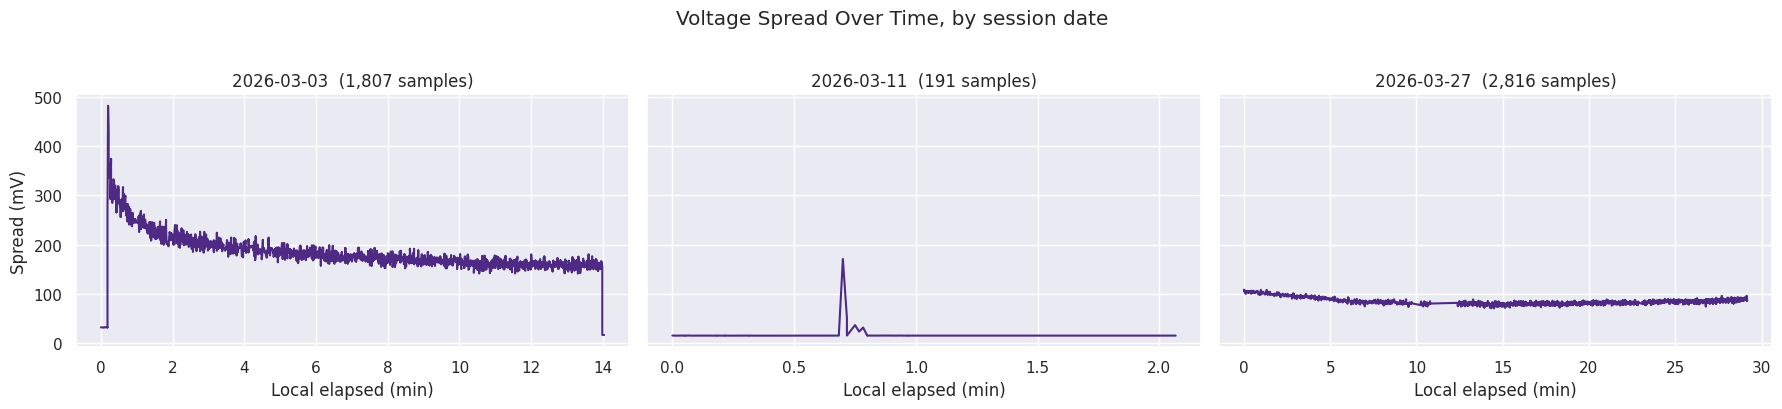

In [4]:
collated['Voltage Spread'] = collated['Highest Cell Volt'] - collated['Lowest Cell Volt']

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, (date, g) in zip(axes, collated.groupby('session_date')):
    # use session-local elapsed time for readability across very different durations
    g = g.copy()
    g['local_s'] = (g['Time'] - g['Time'].iloc[0]).dt.total_seconds()
    ax.plot(g['local_s'] / 60, g['Voltage Spread'] * 1000, color='#4E2A84')
    ax.set_title(f'{date}  ({len(g):,} samples)')
    ax.set_xlabel('Local elapsed (min)')
axes[0].set_ylabel('Spread (mV)')
fig.suptitle('Voltage Spread Over Time, by session date', y=1.02)
plt.tight_layout()
plt.show()

**Per-cell z-score across sessions**

A heatmap of z-score by (cell, session). Cells repeatedly red (low) or
dark (high) are persistent outliers worth physical inspection; cells that
flip sign or only appear once are noisier signals.

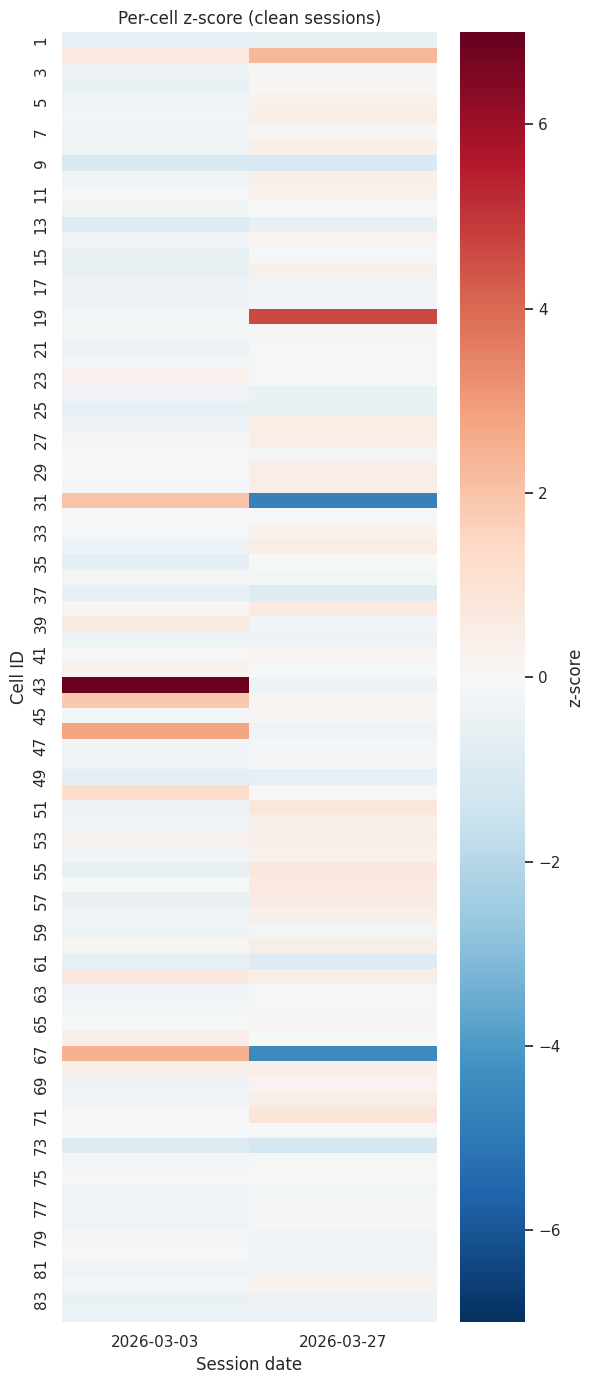

In [5]:
z_wide = metrics_clean.pivot(index='cell_id', columns='session_date', values='z')

fig, ax = plt.subplots(figsize=(6, 14))
sns.heatmap(z_wide, cmap='RdBu_r', center=0, vmin=-7, vmax=7,
            annot=False, cbar_kws={'label': 'z-score'}, ax=ax)
ax.set_title('Per-cell z-score (clean sessions)')
ax.set_xlabel('Session date')
ax.set_ylabel('Cell ID')
plt.tight_layout()
plt.show()

**Rank stability between sessions**

Plot of each cell's mean rank in session A vs. session B. Cells on the
diagonal kept their position in the pack ordering; cells far off-diagonal
drifted between sessions — usually a more interesting signal than absolute
voltage because rank is robust to global pack drift.

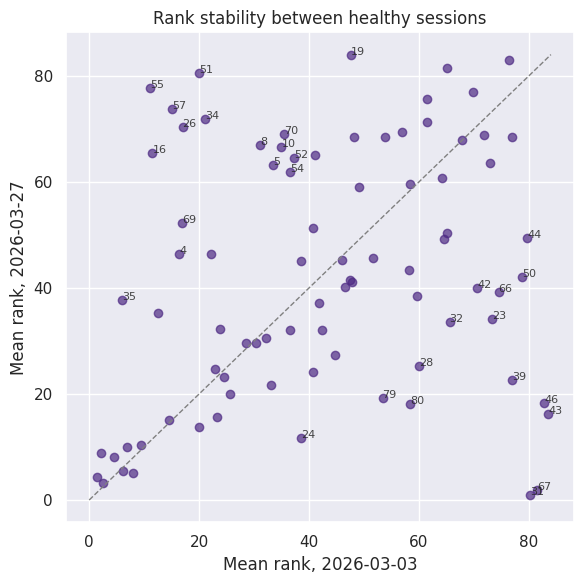

In [6]:
ranks_wide = metrics_clean.pivot(index='cell_id', columns='session_date', values='mean_rank')
dates = sorted(ranks_wide.columns)
a, b = dates[0], dates[-1]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(ranks_wide[a], ranks_wide[b], color='#4E2A84', alpha=0.7)
ax.plot([0, B.N_CELLS], [0, B.N_CELLS], color='gray', linestyle='--', linewidth=1)
for cid in ranks_wide.index:
    dx = ranks_wide.loc[cid, b] - ranks_wide.loc[cid, a]
    if abs(dx) > 25:
        ax.annotate(str(cid), (ranks_wide.loc[cid, a], ranks_wide.loc[cid, b]),
                    fontsize=8, alpha=0.85)
ax.set_xlabel(f'Mean rank, {a}')
ax.set_ylabel(f'Mean rank, {b}')
ax.set_title('Rank stability between healthy sessions')
plt.tight_layout()
plt.show()

**Cells flagged in multiple healthy sessions**

Union of the bottom-5 and top-5 z-scores across each clean session. Cells
appearing in multiple sessions are the durable signals; one-offs are usually
noise that won't reproduce. Counts how many sessions each cell shows in.

In [7]:
flagged = {}
for date, g in metrics_clean.groupby('session_date'):
    for cid in g.nsmallest(5, 'z')['cell_id'].tolist():
        flagged.setdefault(cid, {'low': 0, 'high': 0})['low'] += 1
    for cid in g.nlargest(5, 'z')['cell_id'].tolist():
        flagged.setdefault(cid, {'low': 0, 'high': 0})['high'] += 1

flagged_df = (pd.DataFrame.from_dict(flagged, orient='index')
               .rename_axis('cell_id').reset_index())
flagged_df['total'] = flagged_df['low'] + flagged_df['high']
flagged_df = flagged_df.sort_values(['total', 'low'], ascending=[False, False])
n_clean = metrics_clean['session_date'].nunique()
print(f'{n_clean} clean session_date(s) considered')
flagged_df

2 clean session_date(s) considered


,cell_id,low,high,total
0,9,2,0,2
2,73,2,0,2
7,67,1,1,2
8,31,1,1,2
1,13,1,0,1
3,49,1,0,1
4,35,1,0,1
10,37,1,0,1
5,43,0,1,1
6,46,0,1,1


**Load residual across sessions**

Median V_loaded − OCV per cell, computed only over samples with |Pack Current| ≥ 1 A
so the delta is dominated by I·R rather than measurement noise. Cells whose
load residual is consistently more negative than the pack are sagging harder
under the same current — a tell for elevated internal resistance.

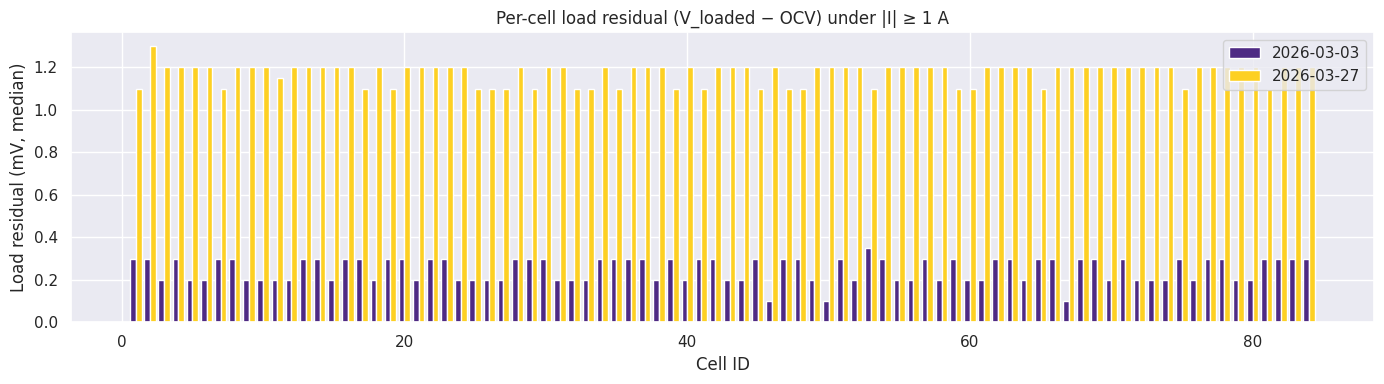

In [8]:
lr_wide = metrics_clean.pivot(index='cell_id', columns='session_date', values='load_residual_mv')

fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(1, B.N_CELLS + 1)
width = 0.4
for i, date in enumerate(sorted(lr_wide.columns)):
    ax.bar(x + (i - 0.5) * width, lr_wide[date].reindex(x).to_numpy(),
           width=width, label=date)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Cell ID')
ax.set_ylabel('Load residual (mV, median)')
ax.set_title('Per-cell load residual (V_loaded − OCV) under |I| ≥ 1 A')
ax.legend()
plt.tight_layout()
plt.show()

**Pack mean voltage across sessions**

Tracks where in the SOC range each session lived. Helps interpret cell-level
comparisons — two sessions at different SOC bands aren't directly comparable
by raw voltage, which is why z-score and rank are the primary trend metrics.

In [9]:
agg = metrics.groupby('session_date').agg(
    pack_mean_v=('mean_voltage', 'mean'),
    pack_std_v=('mean_voltage', 'std'),
    samples=('cell_id', 'count'),
).round(4)
agg['samples'] = agg['samples'] // B.N_CELLS  # convert from cell-rows back to sessions
agg

,pack_mean_v,pack_std_v,samples
session_date,,,
2026-03-03,3.6247,0.0226,1
2026-03-11,3.5769,0.2845,1
2026-03-27,3.7084,0.0090,1


## Conclusion

### Reading the trend metrics
The z-score heatmap and the multi-session flagged-cells table are the single
most useful artifacts for deciding which cells to act on. A cell that's a
−2σ outlier in **one** session is roughly the bottom-5 noise floor; a cell
that's a −2σ outlier in **both** healthy sessions is a durable signal.

### Cells confirmed across sessions
Cells **31** and **67** appear as elevated outliers in 2026-03-03 (z = +2.0 and
+2.5) and as the dominant low-side outliers in 2026-03-27 (z = −6.3 and −4.5).
This sign flip across sessions is consistent with a cell that started slightly
ahead — i.e., reaching higher voltage faster under charge — and has since lost
capacity, now reaching lower voltage at the same SOC. The same signature was
what cell 43 showed before its session-2 collapse. Recommend physical inspection
of cells 31 and 67 alongside the already-scheduled work.

### Fault session (2026-03-11)
Excluded from trend metrics. Cell 43 collapse to ~0 V dominates the day's
z-score distribution and would otherwise compress all other cells toward zero
in the heatmap.

### Next steps
Re-run after each new session. Watch the heatmap for new cells acquiring
persistent z-score color; that's the leading indicator before a P0A80 fault.
Two or three more healthy sessions will let rank-stability be the primary
trend metric — once stable, any cell whose rank drifts by >25 positions is
the next escalation candidate.